In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import ruptures as rpt
from IPython.display import Audio, display

In [2]:
def fig_ax(figsize=(15, 5), dpi=150):
    """Return a (matplotlib) figure and ax objects with given size."""
    return plt.subplots(figsize=figsize, dpi=dpi)

In [3]:
signal, sampling_rate = librosa.load("../data/test2.m4a")


/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_37080/1374190354.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sampling_rate = librosa.load("../data/test2.m4a")
/Users/kotaro.ambai/Desktop/analyze_apple_healthcare_data/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [4]:
signal.shape

(746965,)

In [5]:
display(Audio(data=signal, rate=sampling_rate))


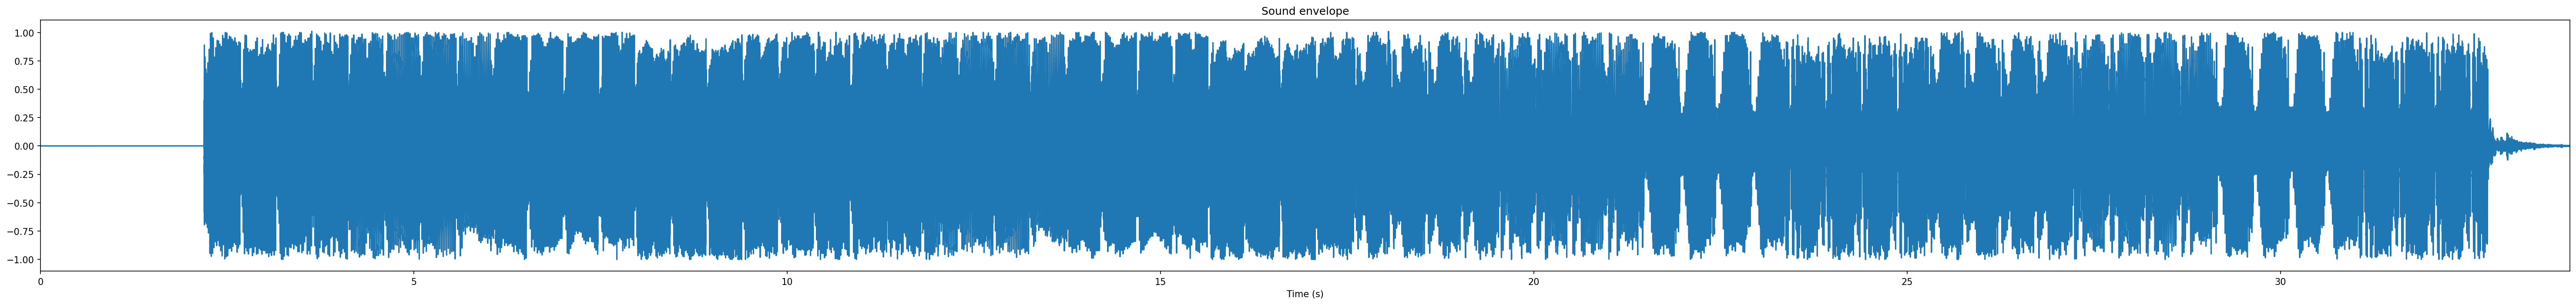

In [6]:
# look at the envelope
fig, ax = fig_ax(figsize=(50, 5))
ax.plot(np.arange(signal.size) / sampling_rate, signal)
ax.set_xlim(0, signal.size / sampling_rate)
ax.set_xlabel("Time (s)")
_ = ax.set(title="Sound envelope")

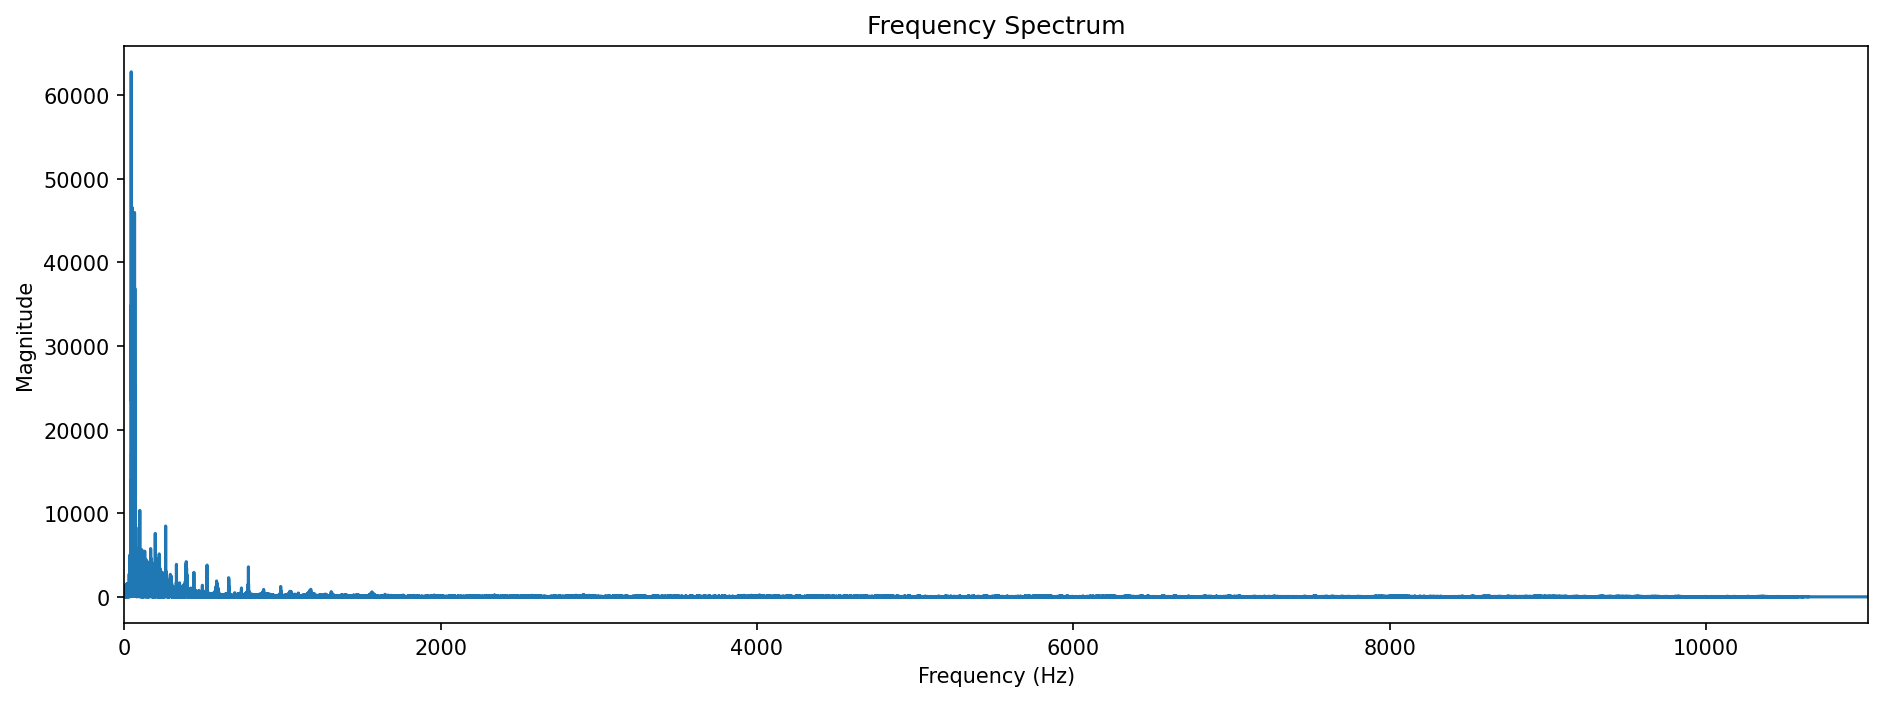

In [7]:
# フーリエ変換
fft_signal = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(fft_signal), 1 / sampling_rate)

# 振幅スペクトルを計算
magnitude = np.abs(fft_signal)

# 周波数スペクトルをプロット
fig, ax = fig_ax()
ax.plot(freqs[: len(freqs) // 2], magnitude[: len(magnitude) // 2])  # 正の周波数成分のみプロット
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("Frequency Spectrum")
ax.set_xlim(0, sampling_rate / 2)  # ナイキスト周波数までの範囲に制限

plt.show()

In [8]:
# # Compute the onset strength
# hop_length_tempo = 256
# oenv = librosa.onset.onset_strength(y=signal, sr=sampling_rate, hop_length=hop_length_tempo)

# # Compute the tempogram
# tempogram = librosa.feature.fourier_tempogram(
#     onset_envelope=oenv,
#     sr=sampling_rate,
#     hop_length=hop_length_tempo,
# )
# # Display the tempogram
# fig, ax = fig_ax()
# _ = librosa.display.specshow(
#     tempogram,
#     ax=ax,
#     hop_length=hop_length_tempo,
#     sr=sampling_rate,
#     x_axis="s",
#     y_axis="tempo",
# )

In [9]:
# https://centre-borelli.github.io/ruptures-docs/examples/music-segmentation/
# algo = rpt.KernelCPD(kernel="linear").fit(signal)
# bkps = algo.predict(n_bkps=4)

In [10]:
# データ量が多いので計算量が多いDyapやKernelCPDは遅い
# 高速な手法を使い比較してみる
len(signal)

746965

In [11]:
def plot_result(signal: np.array, sampling_rate: int, change_points: list, figsize: tuple) -> None:
    # look at the envelope
    fig, ax = fig_ax(figsize=figsize)
    ax.plot(np.arange(signal.size) / sampling_rate, signal)
    for bk in change_points:
        ax.axvline(x=bk / sampling_rate, color="r", linestyle="--")

    ax.set_xlim(0, signal.size / sampling_rate)
    ax.set_xlabel("Time (s)")
    _ = ax.set(title="Sound envelope")

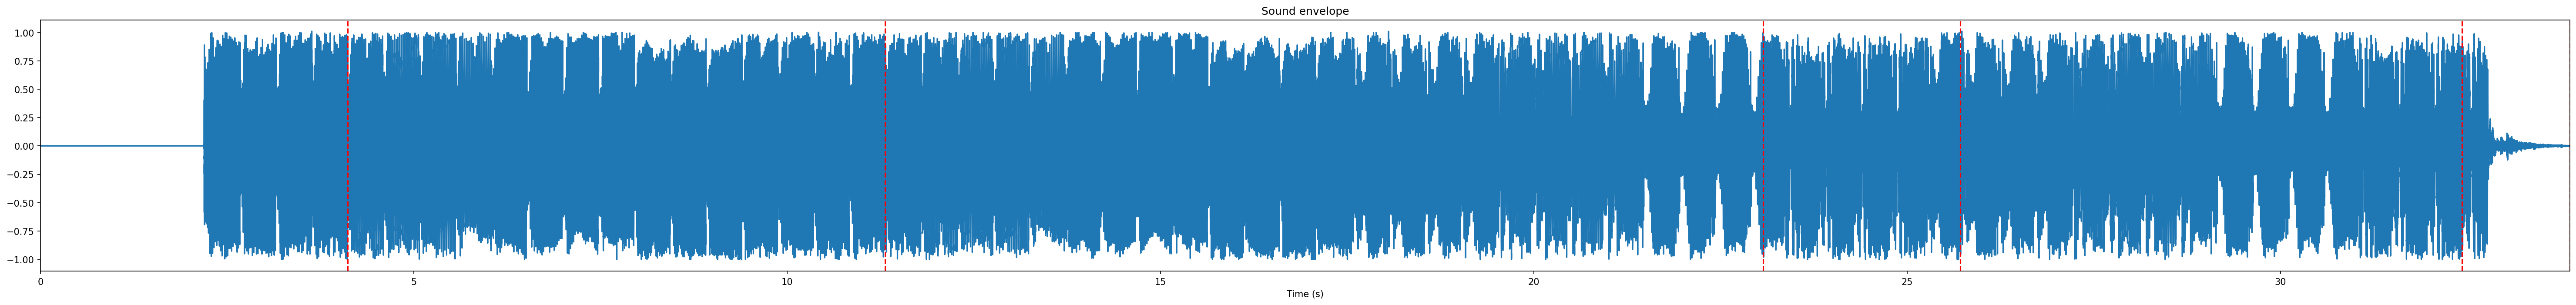

In [12]:
# window
model = "l2"
algo = rpt.Window(width=5, model=model).fit(signal)
change_points = algo.predict(n_bkps=5)
plot_result(signal=signal, sampling_rate=sampling_rate, change_points=change_points, figsize=(50, 5))

In [13]:
for c in change_points:
    print(f"Change point at {c / sampling_rate} s")

Change point at 4.109070294784581 s
Change point at 11.309070294784581 s
Change point at 23.070294784580497 s
Change point at 25.710884353741495 s
Change point at 32.43015873015873 s
Change point at 33.87596371882086 s
